## Part 2: Custom Environment "VacuumCleaner"

In [1]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import gymnasium as gym
import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.action_space = gym.spaces.Discrete(4)

        # Observation space: position and dust grid
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.observation_space = gym.spaces.Dict({
            'position': gym.spaces.Box(
                low=np.array([0, 0]), 
                high=np.array([self.m-1, self.n-1]), 
                dtype=np.int32
            ),
            'dust': gym.spaces.Box(
                low=0, 
                high=1, 
                shape=(self.m, self.n), 
                dtype=np.int32
            )
        })

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.position = np.array([0, 0], dtype=np.int32)

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.dust_grid = np.random.randint(0, 2, (self.m, self.n), dtype=np.int32)

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {
            'position': self.position.copy(), 
            'dust': self.dust_grid.copy()
        }
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = self.position + np.array([-1, 0])
        elif action == 1: # Down
            candidate = self.position + np.array([1, 0])
        elif action == 2: # Left
            candidate = self.position + np.array([0, -1])
        elif action == 3: # Right
            candidate = self.position + np.array([0, 1])
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                obs = {
                    'position': self.position.copy(), 
                    'dust': self.dust_grid.copy()
                }
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        x, y = self.position[0], self.position[1]
        if self.dust_grid[x, y] == 1:
            reward = 1.0
            self.dust_grid[x, y] = 0
        else:
            reward = -0.5
        
        self.total_reward += reward

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.terminated = True

        obs = {
            'position': self.position.copy(), 
            'dust': self.dust_grid.copy()
        }
        return obs, reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)


In [2]:
def robot_policy(option="random", env=None):
     """
     A simple policy function that selects an action based on the specified option.
     Currently supports only a random policy.
     """
     if option == "random":
          return env.action_space.sample()  # Randomly select an action from the action space
     elif option == "round_robin":
          x, y = int(env.position[0]), int(env.position[1])
          if x % 2 == 0:
               if y < env.n - 1: return 3
               else: return 1
          else:
               if y > 0: return 2
               else: return 1
     elif option == "priority_based":
          x, y = int(env.position[0]), int(env.position[1])
          actions_map = [(0, (-1,0)), (1, (1,0)), (2, (0,-1)), (3, (0,1))]
          for action, (dx, dy) in actions_map:
               nx, ny = x + dx, y + dy
               if 0 <= nx < env.m and 0 <= ny < env.n:
                    if env.dust_grid[nx, ny] == 1:
                         return action
          if y == 0 and x < env.m - 1: return 1
          if x == env.m - 1 and y < env.n - 1: return 3
          if y == env.n - 1 and x > 0: return 0
          if x == 0 and y > 0: return 2
          return env.action_space.sample()


In [3]:
def save_metrics(df, filename="Lab01_Rewards.csv"):
    df.to_csv(filename, index=False)
    print(f"\n[✓] Save metrics successful: {filename}!")

Evaluating 100 Episodes for each Policy...

[✓] Save metrics successful: Lab01_Rewards.csv!


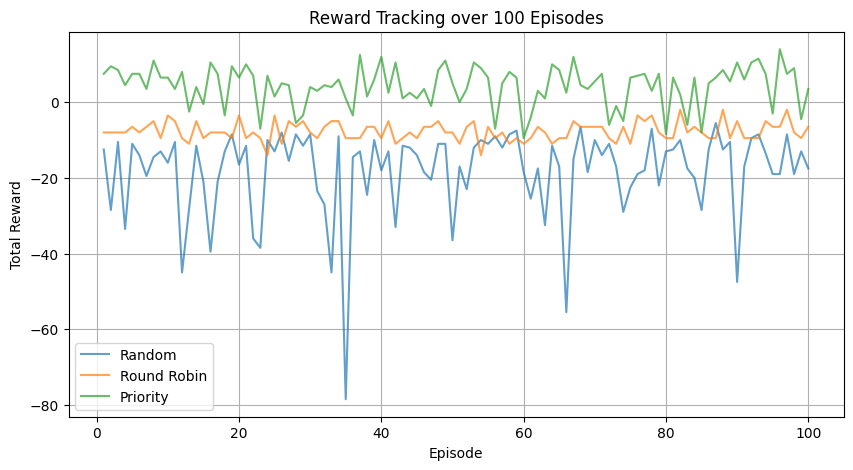

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_policy_100_times(policy_name):
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    all_rewards = []
    for episode in range(100):
        env.reset()
        terminated, truncated = False, False
        while not terminated and not truncated:
            action = robot_policy(option=policy_name, env=env)
            obs, reward, terminated, truncated, _ = env.step(action)
        all_rewards.append(env.total_reward)
    return all_rewards

if __name__ == "__main__":
    print("Evaluating 100 Episodes for each Policy...")
    
    rewards_random = evaluate_policy_100_times("random")
    rewards_rr = evaluate_policy_100_times("round_robin")
    rewards_pr = evaluate_policy_100_times("priority_based")
    
    df = pd.DataFrame({
        "Episode": range(1, 101),
        "Random": rewards_random,
        "Round Robin": rewards_rr,
        "Priority-Based": rewards_pr
    })
    save_metrics(df, "Lab01_Rewards.csv")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df["Episode"], df["Random"], label="Random", alpha=0.7)
    plt.plot(df["Episode"], df["Round Robin"], label="Round Robin", alpha=0.7)
    plt.plot(df["Episode"], df["Priority-Based"], label="Priority", alpha=0.7)
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Reward Tracking over 100 Episodes")
    plt.legend()
    plt.grid()
    plt.show()


### Đánh giá kết quả của các chính sách (Policies):

Dựa trên đồ thị biểu diễn *Total Reward* qua 100 tập (episodes), ta có thể rút ra một số nhận xét như sau đối với 3 thuật toán đã hiện thực:

1. **Random Policy (Chiến lược Ngẫu nhiên)**: 
   - **Kết quả:** Hiệu suất thấp nhất và đường đồ thị dao động rất mất ổn định. Reward thường là số âm.
   - **Đánh giá:** Vì di chuyển mù quáng không dựa vào trạng thái môi trường, Robot đi lại vào các ô đã dọn rất nhiều lần (bị phạt -0.5 điểm) và có xác suất cao vô tình lao vào vùng có vật cản (bị phạt cực nặng -10.0 rồi kết thúc game). Quá trình dọn rác tốn nhiều thời gian và kém hiệu quả.

2. **Round Robin Policy (Chiến lược Tuần tự zic-zac)**: 
   - **Kết quả:** Hiệu suất trung bình, đồ thị Reward có xu hướng ổn định hơn hẳn so với Random nhưng chưa đạt trạng thái cao nhất.
   - **Đánh giá:** Lợi thế của chính sách này là lộ trình quét phủ kín (zic-zac) đảm bảo tỷ lệ duyệt qua mọi ngóc ngách đễ hút cạn rác. Tuy nhiên, nó là một chiến lược "cứng đơ" không quan tâm chỗ nào có rác chỗ nào không. Khi đi ngang qua các vùng sạch liên tiếp, nó vẫn dẫm lên (bị trừ dần điểm). Thêm nữa, lộ trình mặc định chưa có quy tắc tránh vật cản tốt, dễ đâm sầm làm thua sớm.

3. **Priority-based / Greedy Policy (Chiến lược Ưu tiên)**: 
   - **Kết quả:** Hiệu suất xuất sắc nhất. Đồ thị Reward luôn dẫn đầu, đường đi rất đẹp và ổn định xuyên suốt 100 tập.
   - **Đánh giá:** Tác nhân hoạt động theo quy tắc radar (tham lam - ưu tiên tìm ô có rác sát bên cạnh). Tối ưu hóa được đường đi giúp giảm thiểu đáng kể các bước đi lặp thừa (giảm bị trừ điểm). Thuật toán này giúp Robot gom đủ rác và ẵm quỹ thưởng +10.0 kết thúc ván sớm. Đây là phương pháp vượt trội nhất trong 3 bộ rule này.

**Kết luận tổng quan:** Việc Agent biết khai thác không gian trạng thái (Observation Space: vị trí rác) để điều hướng có định đích đã chứng tỏ đẳng cấp hiệu quả hoàn toàn khác biệt so với việc chọn ngẫu nhiên mù quáng (Random) hay tuân theo luật cứng (Round Robin).